In [1]:
from PIL import Image
from PIL import ImageOps
import numpy as np
import pandas as pd
import sys

#from gdpc import __url__, Editor, Block

#editor = Editor(buffering=True)

# Open image
img = Image.open("maps/geologic_map_from_data.png")
img = img.convert('RGB')

# Resize smoothly down to 32x32 pixels
img = img.resize((577,428), resample=Image.Resampling.NEAREST)

#posterize image to smooth rgb values
img_p = ImageOps.posterize(img, 2) 

# Scale back up using NEAREST to original size
#map_pixel_big = map_pixel.resize(img.size, Image.Resampling.NEAREST)
#pixel_post_big = pixel_post.resize(img.size, Image.Resampling.NEAREST)

# Save
img.save('map.png')
img_p.save('posterized.png')

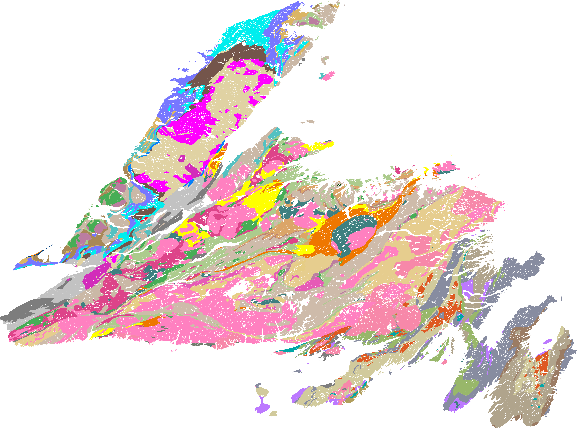

In [2]:
img

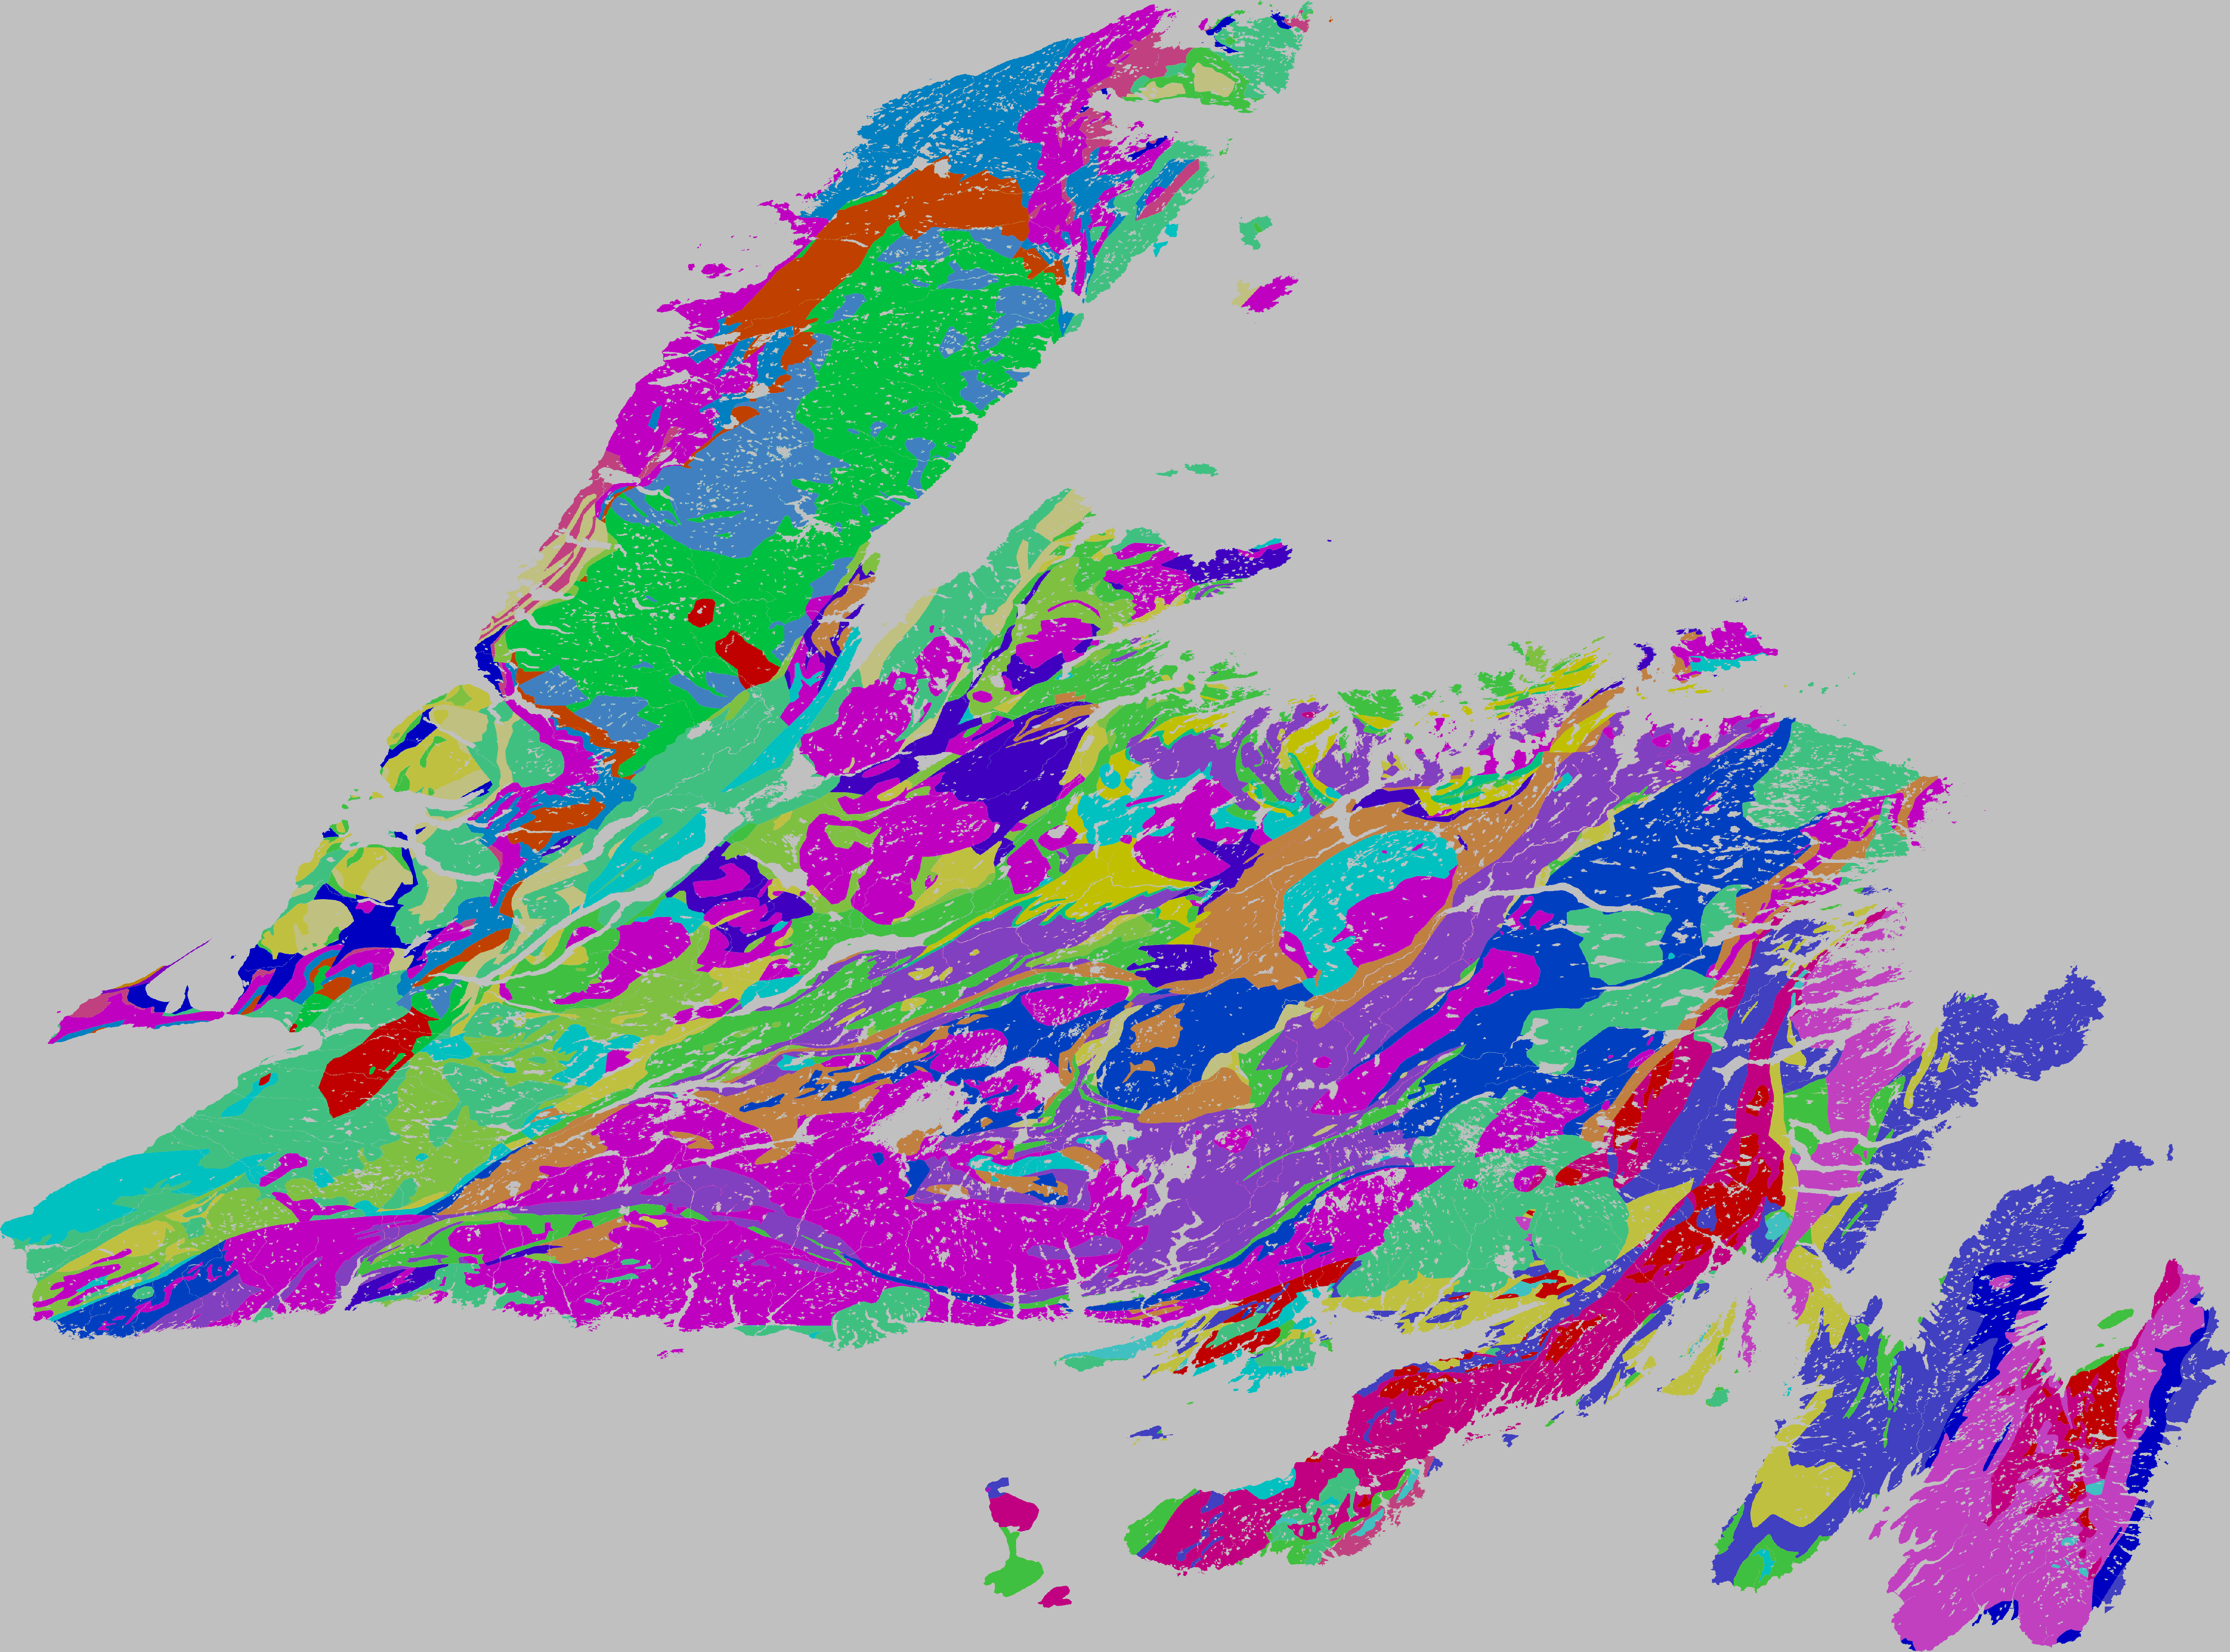

In [26]:
img_p

In [3]:
arr = np.array(img)
arr = arr[:,:,:3]
arr_p = np.array(img_p)
arr_p = arr_p[:,:,:3]
arr[200:205, 200:205]


array([[[194, 194, 194],
        [194, 194, 194],
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[194, 194, 194],
        [194, 194, 194],
        [220, 220, 220],
        [255, 255, 255],
        [255, 255, 255]],

       [[243, 243, 243],
        [201, 201, 201],
        [194, 194, 194],
        [195, 195, 195],
        [255, 255, 255]],

       [[195, 195, 195],
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[194, 194, 194],
        [255, 255, 255],
        [255, 255, 255],
        [226, 226, 226],
        [255, 255, 255]]], dtype=uint8)

In [6]:
rows, cols, z = arr.shape
arr_fix = np.empty(shape=(rows,cols,z), dtype = int)
for x in range(rows):
    for y in range(cols):
        if (np.array_equal(arr[x,y],[  0, 166, 166])
        or np.array_equal(arr[x,y],[  0, 238, 238])
        or np.array_equal(arr[x,y],[  0,  64,   0])
        or np.array_equal(arr[x,y],[  0,  64, 128])
        or np.array_equal(arr[x,y],[101, 229, 101])
        or np.array_equal(arr[x,y],[112, 124, 109])
        or np.array_equal(arr[x,y],[116,  85,  75])
        or np.array_equal(arr[x,y],[119, 119, 255])
        or np.array_equal(arr[x,y],[125, 125, 125])
        or np.array_equal(arr[x,y],[135, 140, 160])
        or np.array_equal(arr[x,y],[152, 183, 106])
        or np.array_equal(arr[x,y],[155, 124, 100])
        or np.array_equal(arr[x,y],[168, 136,  87])
        or np.array_equal(arr[x,y],[172, 203, 141])
        or np.array_equal(arr[x,y],[176, 164, 140])
        or np.array_equal(arr[x,y],[177, 158,  92])
        or np.array_equal(arr[x,y],[186, 130, 118])
        or np.array_equal(arr[x,y],[186, 165, 150])
        or np.array_equal(arr[x,y],[187, 125, 160])
        or np.array_equal(arr[x,y],[188, 121, 255])
        or np.array_equal(arr[x,y],[194, 194, 194])
        or np.array_equal(arr[x,y],[202, 184, 166])
        or np.array_equal(arr[x,y],[206, 187, 170])
        or np.array_equal(arr[x,y],[209, 202, 156])
        or np.array_equal(arr[x,y],[210,  45, 186])
        or np.array_equal(arr[x,y],[219, 165, 104])
        or np.array_equal(arr[x,y],[219, 181, 100])
        or np.array_equal(arr[x,y],[221,  68, 137])
        or np.array_equal(arr[x,y],[222,  89,  33])
        or np.array_equal(arr[x,y],[224, 210, 163])
        or np.array_equal(arr[x,y],[229, 101, 101])
        or np.array_equal(arr[x,y],[229, 127,   0])
        or np.array_equal(arr[x,y],[230, 205, 132])
        or np.array_equal(arr[x,y],[230, 205, 142])
        or np.array_equal(arr[x,y],[230,  91, 182])
        or np.array_equal(arr[x,y],[238, 119,   0])
        or np.array_equal(arr[x,y],[247, 136, 169])
        or np.array_equal(arr[x,y],[255,   0, 255])
        or np.array_equal(arr[x,y],[255,   0,  50])
        or np.array_equal(arr[x,y],[255, 128,   0])
        or np.array_equal(arr[x,y],[255, 128, 192])
        or np.array_equal(arr[x,y],[255, 153,  50])
        or np.array_equal(arr[x,y],[255, 229, 255])
        or np.array_equal(arr[x,y],[255, 255,   0])
        or np.array_equal(arr[x,y],[255,  50, 204])
        or np.array_equal(arr[x,y],[  6, 128, 249])
        or np.array_equal(arr[x,y],[ 62, 128, 128])
        or np.array_equal(arr[x,y],[ 71, 173,  86])
        or np.array_equal(arr[x,y],[ 83, 193, 193])
        or np.array_equal(arr[x,y],[255, 255, 255])):
            arr_fix[x,y] = arr[x,y]
        else:
            arr_fix[x,y] = arr_fix[x-1,y]

In [12]:

img_fix = Image.fromarray((arr_fix).astype(np.uint8))
img_fix.save('maps/geologic_map_rgb_fixed.png')

In [17]:
#rgb=''.join(str(x) for x in arr_p)
arr_rgb = np.empty(shape=(rows,cols), dtype = int)
rows, cols, z = arr_fix.shape
for x in range(rows):  
    for y in range(cols):
        arr_rgb[x,y] = ''.join(str(n) for n in arr_fix[x,y])
        #rgb = int(rgb)
        #arr_rgb[x, y] = rgb
arr_rgb.shape

(428, 577)

In [18]:
unique = np.unique(arr_rgb)
print(unique)

[      640     64128    166166    238238    255050   1168575   2228933
   2381190   2550255   2551280   2552550   6128249   7117386  16813687
  17715892  21045186  22168137  23091182  62128128  83193193 112124109
 119119255 125125125 135140160 152183106 155124100 172203141 176164140
 186130118 186165150 187125160 188121255 194194194 202184166 206187170
 209202156 219165104 219181100 224210163 230205132 230205142 247136169
 255128192 255229255 255255255]


In [23]:
arr_flip=np.flip(arr_rgb,axis=1)


In [56]:
print(pd.DataFrame(arr_rgb))
df = pd.DataFrame(arr_rgb)
df.to_csv('arr_rgb_test.csv')

           0          1          2          3          4          5   \
0   240240240  240240240  240240240  240240240  240240240  240240240   
1   240240240  240240240  240240240  240240240  240240240  240240240   
2   240240240  240240240  240240240  240240240  240240240  240240240   
3   240240240  240240240  240240240  240240240  240240240   48208224   
4   240240240  240240240  240240240  240240240  240240240   19296224   
5   240240240  240240240  240240240  240240240  192160112   24048240   
6   240240240  240240240  240240240  240240240  224208160  224208160   
7   240240240  240240240  240240240  240240240  208192160  208208192   
8   240240240  240240240  240240240  112192112   80208208  240240192   
9   240240240  240240240  240240240  144144240  112176112  224112144   
10  240240240  240240240  240240240  224160176   22496144  176208144   
11  240240240  240240240  208208192  224112144  224208144  208192176   
12  240240240   22496144  240144192  192176160  240160192  24016

In [105]:
for x in range (0,16):
    for z in range(0,16):
        if arr_all[x,z]==765:
            editor.placeBlock((x,-60,z), Block("white_wool"))

NameError: name 'editor' is not defined